In [ ]:
# MDAR / q-Regime Analysis

This notebook reproduces the q-regime analysis based on fitted SPARC rotation-curve results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("q_fit_results.csv")
print(df.head())
print(df.columns)

              filename         p         q       MSE  n_points
0   UGCA444_rotmod.dat  1.459703  3.000000  0.003141        36
1   UGCA442_rotmod.dat  2.044649  0.485413  0.000330         8
2   UGCA281_rotmod.dat  1.943306  0.581791  0.000616         7
3  UGC12732_rotmod.dat  0.781112  3.000000  0.001713        16
4  UGC12632_rotmod.dat  1.273916  0.679549  0.001109        15
Index(['filename', 'p', 'q', 'MSE', 'n_points'], dtype='object')


In [3]:
def get_type(name):
    if name.startswith("DDO") or name.startswith("D"):
        return "Dwarf"
    elif name.startswith("F"):
        return "LSB"
    elif name.startswith("ESO"):
        return "ESO"
    elif name.startswith("IC") or name.startswith("KK"):
        return "IC"
    elif name.startswith("NGC"):
        return "NGC"
    elif name.startswith("UGC") or name.startswith("UGCA"):
        return "UGC"
    else:
        return "Other"

if "type" not in df.columns:
    df["type"] = df["filename"].apply(get_type)

In [4]:
def get_regime(q):
    if q < 1.2:
        return "Peak"
    elif q > 2.5:
        return "Diffuse"
    else:
        return "Transition"

df["regime"] = df["q"].apply(get_regime)

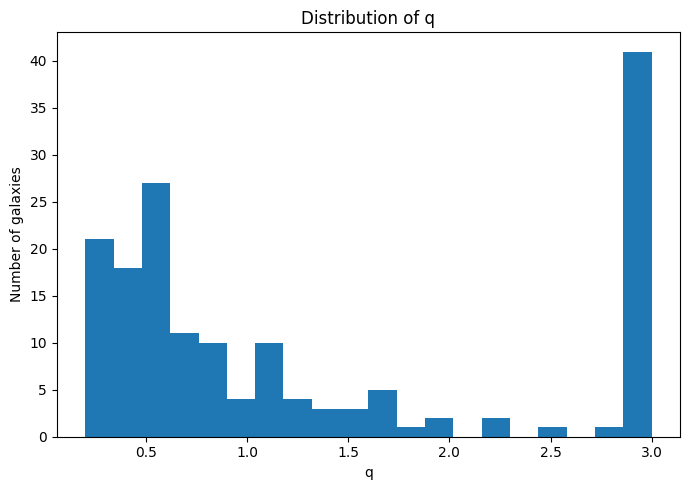

In [5]:
plt.figure(figsize=(7,5))
plt.hist(df["q"], bins=20)
plt.xlabel("q")
plt.ylabel("Number of galaxies")
plt.title("Distribution of q")
plt.tight_layout()
plt.savefig("q_histogram.png", dpi=300)
plt.show()

<Figure size 800x500 with 0 Axes>

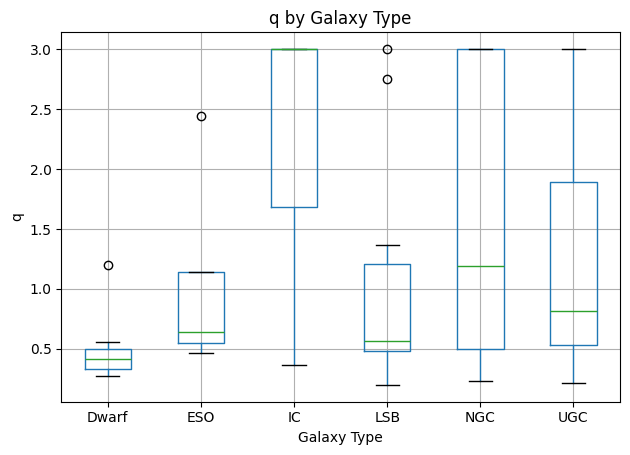

In [6]:
plt.figure(figsize=(8,5))
df.boxplot(column="q", by="type")
plt.title("q by Galaxy Type")
plt.suptitle("")
plt.xlabel("Galaxy Type")
plt.ylabel("q")
plt.tight_layout()
plt.savefig("q_by_type.png", dpi=300)
plt.show()

In [7]:
table_counts = pd.crosstab(df["type"], df["regime"])
table_percent = pd.crosstab(df["type"], df["regime"], normalize="index") * 100

print(table_counts)
print(table_percent.round(1))

regime  Diffuse  Peak  Transition
type                             
Dwarf         0     6           1
ESO           0     3           1
IC            2     1           0
LSB           2    11           2
NGC          21    30           9
UGC          17    51           7
regime  Diffuse  Peak  Transition
type                             
Dwarf       0.0  85.7        14.3
ESO         0.0  75.0        25.0
IC         66.7  33.3         0.0
LSB        13.3  73.3        13.3
NGC        35.0  50.0        15.0
UGC        22.7  68.0         9.3


In [8]:
table_counts.to_csv("regime_summary.csv")